In [1]:
# a simple polynomial regression

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
# we will take some 200 random points between 0,1
X =  6 * np.random.rand(200, 1) - 3
y = (0.8 * X**2) + (0.9 * X) + 2 + np.random.randn(200, 1)
# our data eqn is y = 0.8 x^2 + 0.9 x + 2, extra is noise

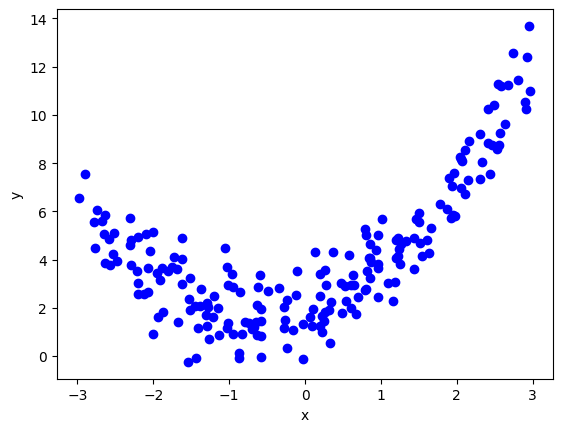

In [6]:
# we will now plot our data to see how it looks like
plt.scatter(X, y, color = 'b')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [7]:
# no we will first try to fit a straight line using normal regression

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 20, test_size= 0.2)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

In [12]:
lr.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test)

In [17]:
# now calculating r2 score for performance
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.16834745552522834

In [18]:
# if we observe the r2 score, it's very less because of the nature of the data

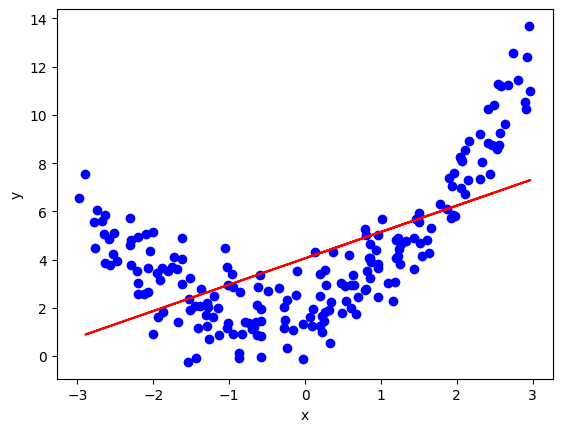

In [19]:
# now we will plot our line on the graph
plt.scatter(X, y, color = 'b')
plt.plot(X_train, lr.predict(X_train), color = 'r')
plt.xlabel("x")
plt.ylabel('y')
plt.show()

In [20]:
# no we will apply polynomial regression of degree 2

In [21]:
# we will first have to scale our input features with degree 2, this can be done by using below
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [22]:
poly = PolynomialFeatures(degree= 2)

In [23]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [24]:
# now our X_train_trans has 3 values for each single value in X_train
print(X_train[0])
print(X_train_trans[0])

[2.46600023]
[1.         2.46600023 6.08115716]


In [25]:
lr = LinearRegression()

In [26]:
lr.fit(X_train_trans, y_train)

LinearRegression()

In [27]:
y_pred = lr.predict(X_test_trans)

In [29]:
r2_score(y_test, y_pred)

0.8394750665249111

In [30]:
# we cam clearly see that our r2 scored imporved by a lot

In [31]:
lr.intercept_

array([1.91467734])

In [32]:
lr.coef_

array([[0.        , 0.94941335, 0.83203434]])

In [33]:
# we can even see our coefficients also matching nearly with the original equation

In [34]:
# now what we will do is, we will take some 200 points between -3, 3 and try to plot our curve on that points and we will see how it appears on top our old points
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
x_new_trans = poly.fit_transform(x_new)
y_new = lr.predict(x_new_trans)

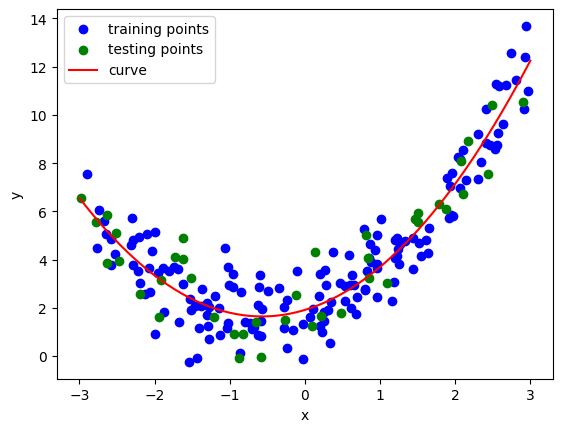

In [36]:
plt.scatter(X_train, y_train, color = 'b', label = 'training points')
plt.scatter(X_test, y_test, color = 'g', label = 'testing points')
plt.plot(x_new, y_new, color = 'r', label = 'curve')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [42]:
# now we will create our own polynomial regression function to see how it different degress work for underfir or overfit
def polynomialregression(degree):
  poly = PolynomialFeatures(degree)
  x_new = np.linspace(-3, 3, 200).reshape(200, 1)
  x_new_trans = poly.fit_transform(x_new)
  X_train_trans = poly.fit_transform(X_train)
  lin_reg = LinearRegression()
  lin_reg.fit(X_train_trans, y_train)
  y_new = lin_reg.predict(x_new_trans)
  plt.scatter(X_train, y_train, color = 'b', label = 'training')
  plt.scatter(X_test, y_test, color = 'g', label = 'test')
  plt.plot(x_new, y_new, color = 'r', label = 'curve')
  plt.legend()
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

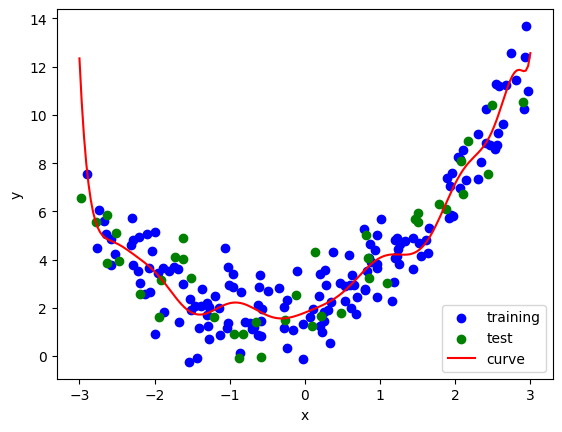

In [47]:
polynomialregression(20)

In [48]:
# if we observe above, the curve is trying to fr with each and every training point thus resulting in overfitting